In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../original_datasets/drone_telemetry.csv')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 42629 entries, 0 to 42628
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   flight_id                42629 non-null  str    
 1   drone_id                 42629 non-null  str    
 2   flight_timestamp         42150 non-null  str    
 3   flight_duration_min      41358 non-null  float64
 4   cumulative_flight_hours  42629 non-null  float64
 5   battery_cycles           42629 non-null  int64  
 6   battery_start_pct        42629 non-null  float64
 7   battery_end_pct          41627 non-null  str    
 8   battery_health_pct       42629 non-null  float64
 9   motor_temp_c             42629 non-null  str    
 10  vibration_rms            41396 non-null  str    
 11  payload_kg               42629 non-null  str    
 12  max_altitude_m           42629 non-null  float64
 13  wind_speed_kmph          42629 non-null  float64
 14  gps_signal_quality       42629 no

In [2]:
print(df.duplicated().sum())

700


In [3]:
df=df.drop_duplicates()

In [4]:
print(df.isna().sum())

flight_id                      0
drone_id                       0
flight_timestamp             467
flight_duration_min         1252
cumulative_flight_hours        0
battery_cycles                 0
battery_start_pct              0
battery_end_pct              985
battery_health_pct             0
motor_temp_c                   0
vibration_rms               1212
payload_kg                     0
max_altitude_m                 0
wind_speed_kmph                0
gps_signal_quality             0
rotor_rpm_avg                735
error_codes                24483
route_deviation_m              0
maintenance_required           0
dtype: int64


In [5]:
# Clean columns
df['payload_kg'] = df['payload_kg'].astype(str).str.replace('kg', '', regex=False).str.strip()
df['payload_kg'] = pd.to_numeric(df['payload_kg'], errors='coerce')

for col in ['battery_end_pct', 'vibration_rms', 'rotor_rpm_avg', 'motor_temp_c']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['gps_signal_quality'] = df['gps_signal_quality'].astype(str).str.strip().str.title()

# Impute missing values
df['flight_duration_min'] = df['flight_duration_min'].fillna(df['flight_duration_min'].median())
df['battery_end_pct'] = df['battery_end_pct'].fillna(df['battery_end_pct'].median())
df['vibration_rms'] = df['vibration_rms'].fillna(df['vibration_rms'].median())
df['rotor_rpm_avg'] = df['rotor_rpm_avg'].fillna(df['rotor_rpm_avg'].median())
df['motor_temp_c'] = df['motor_temp_c'].fillna(df['motor_temp_c'].median())

df['flight_timestamp'] = df['flight_timestamp'].fillna('Unknown')
df['error_codes'] = df['error_codes'].fillna('NONE')

# Save fully cleaned dataset
df.to_csv('cleaned_drone_telemetry_final.csv', index=False)

print("Final dataset shape:", df.shape)
print("Total null values remaining:", df.isnull().sum().sum())


Final dataset shape: (41929, 19)
Total null values remaining: 0


In [8]:
# Let's compute correlations with maintenance_required
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()['maintenance_required'].sort_values(ascending=False)
print("Correlation with maintenance_required:")
print(corr)

Correlation with maintenance_required:
maintenance_required       1.000000
motor_temp_c               0.505640
vibration_rms              0.497319
battery_cycles             0.277677
cumulative_flight_hours    0.277677
payload_kg                 0.140565
route_deviation_m          0.097401
wind_speed_kmph            0.073443
flight_duration_min        0.002805
rotor_rpm_avg              0.001543
max_altitude_m            -0.009245
battery_start_pct         -0.010783
battery_end_pct           -0.095300
battery_health_pct        -0.317906
Name: maintenance_required, dtype: float64


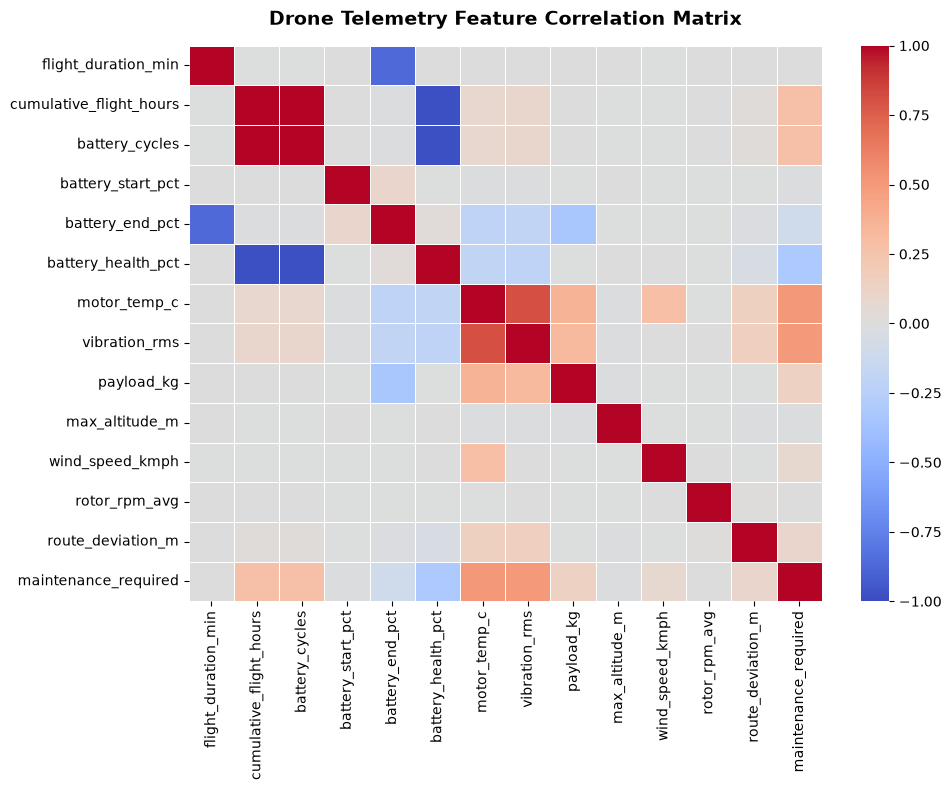

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_17676\3965328480.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='maintenance_required', y='motor_temp_c', data=df, palette='Set2', ax=axes[0])
C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_17676\3965328480.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='maintenance_required', y='vibration_rms', data=df, palette='Set2', ax=axes[1])


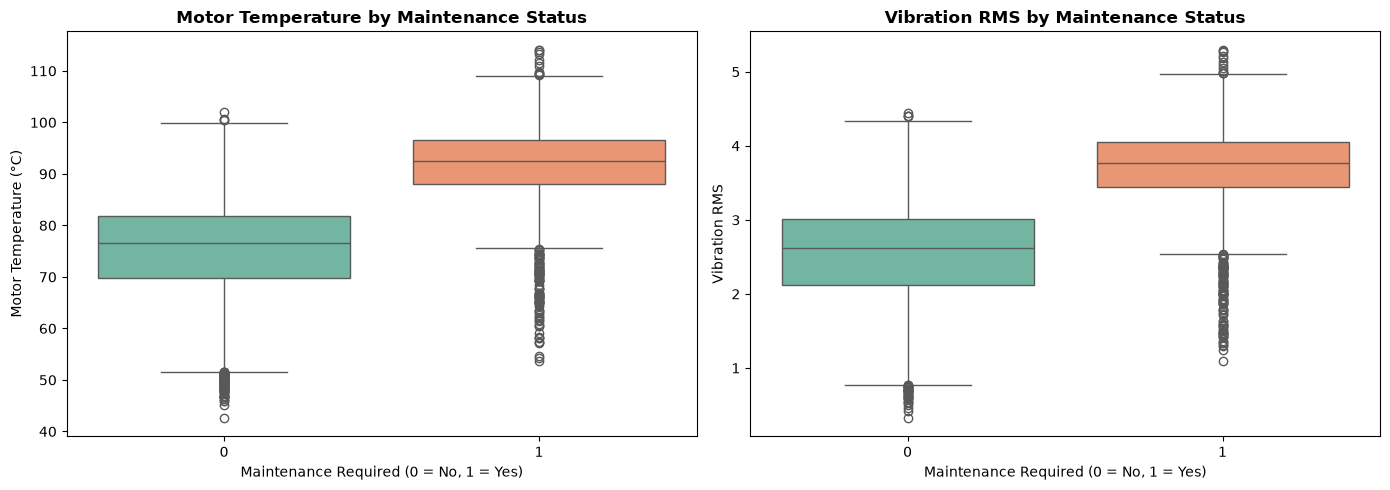

In [7]:
# Figure 1: Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Drone Telemetry Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
plt.close()

# Figure 2: Motor Temperature & Vibration vs Maintenance Required
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='maintenance_required', y='motor_temp_c', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Motor Temperature by Maintenance Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Maintenance Required (0 = No, 1 = Yes)', fontsize=10)
axes[0].set_ylabel('Motor Temperature (°C)', fontsize=10)

sns.boxplot(x='maintenance_required', y='vibration_rms', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Vibration RMS by Maintenance Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Maintenance Required (0 = No, 1 = Yes)', fontsize=10)
axes[1].set_ylabel('Vibration RMS', fontsize=10)

plt.tight_layout()
plt.show()
plt.close()